# 점수 예측 (Score Prediction)

NBA play-by-play 데이터를 사용해 **각 이벤트 시점에서 두 팀이 경기 종료까지 추가로 득점할 점수**를 예측하는 LSTM 모델을 학습합니다.

전체 흐름:
1. **데이터 다운로드** — Kaggle에서 `pbp2023.csv`(2023시즌 NBA 이벤트 로그) 사용
2. **전처리** — clock 파싱, 누적/잔여 점수 계산, 이벤트 타입 정수 인코딩, 게임 단위 시퀀스화
3. **Dataset / DataLoader** — 가변 길이 시퀀스 패딩 및 valid_mask 생성
4. **모델 학습** — Embedding + LSTM + MLP regressor, masked SmoothL1 손실
5. **시각화** — 학습 곡선과 테스트셋 예측 비교

## 학습 데이터 설치


In [28]:
import os
from pathlib import Path

# Windows에서 Jupyter + PyTorch + NumPy 동시 사용 시 OpenMP 런타임 중복 로딩으로
# 커널이 죽는 문제가 있어 우회 옵션을 켠다. 다른 OS에서는 영향 없음.
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"

import numpy as np
import pandas as pd


In [29]:
# dataset/pbp2023.csv 가 없으면 kagglehub 으로 자동 다운로드한다.
# (Kaggle 계정 인증이 필요한 경우 콘솔에서 한 번 로그인해두어야 한다.)
data_dir = Path("dataset")
csv_path = data_dir / "pbp2023.csv"

if not csv_path.exists():
    try:
        import kagglehub

        downloaded_path = Path(
            kagglehub.dataset_download(
                "szymonjwiak/nba-play-by-play-data-1997-2023",
                output_dir="dataset",
            )
        )
        csv_path = downloaded_path / "pbp2023.csv"
    except Exception as exc:
        raise FileNotFoundError(
            "dataset not found"
        ) from exc

print(f"Using dataset file: {csv_path}")


Using dataset file: dataset\pbp2023.csv


In [30]:
# 원본 CSV 미리보기 — gameid, season 은 0으로 시작할 수 있어 문자열로 읽는다.
raw_df = pd.read_csv(csv_path, dtype={"gameid": str, "season": str})
print("rows:", len(raw_df), "| games:", raw_df["gameid"].nunique())
print("columns:", list(raw_df.columns))
raw_df.head(10)


rows: 646971 | games: 1320
columns: ['gameid', 'period', 'clock', 'h_pts', 'a_pts', 'team', 'playerid', 'player', 'type', 'subtype', 'result', 'x', 'y', 'dist', 'desc', 'season']


,gameid,period,clock,h_pts,a_pts,team,playerid,player,type,subtype,result,x,y,dist,desc,season
0,0022200001,1,PT12M00.00S,0.0,0.0,NaN,0,NaN,period,start,NaN,0,0,0,Start of 1st Period (7:36 PM EST),2023
1,0022200001,1,PT12M00.00S,NaN,NaN,BOS,201143,A. Horford,Jump Ball,NaN,NaN,0,0,0,Jump Ball Horford vs. Embiid: Tip to Harris,2023
2,0022200001,1,PT11M38.00S,NaN,NaN,PHI,203954,J. Embiid,Missed Shot,Turnaround Fadeaway shot,Missed,-118,50,13,MISS Embiid 13' Turnaround Fadeaway Shot,2023
3,0022200001,1,PT11M38.00S,NaN,NaN,BOS,1627759,J. Brown,NaN,NaN,NaN,0,0,0,Brown BLOCK (1 BLK),2023
4,0022200001,1,PT11M35.00S,NaN,NaN,PHI,200782,P. Tucker,Rebound,Unknown,NaN,0,0,0,Tucker REBOUND (Off:1 Def:0),2023
5,0022200001,1,PT11M35.00S,NaN,NaN,PHI,200782,P. Tucker,Turnover,Out of Bounds Lost Ball Turnover,NaN,0,0,0,Tucker Out of Bounds Lost Ball Turnover (P1.T1),2023
6,0022200001,1,PT11M15.00S,2.0,0.0,BOS,203935,M. Smart,Made Shot,Driving Floating Bank Jump Shot,Made,120,55,13,Smart 13' Driving Floating Bank Jump Shot (2 PTS),2023
7,0022200001,1,PT11M05.00S,NaN,NaN,PHI,202699,T. Harris,Missed Shot,Driving Floating Jump Shot,Missed,50,135,14,MISS Harris 14' Driving Floating Jump Shot,2023
8,0022200001,1,PT11M05.00S,NaN,NaN,PHI,202699,T. Harris,Rebound,Unknown,NaN,0,0,0,Harris REBOUND (Off:1 Def:0),2023
9,0022200001,1,PT11M03.00S,2.0,2.0,PHI,202699,T. Harris,Made Shot,Tip Layup Shot,Made,0,0,0,Harris Tip Layup Shot (2 PTS),2023


## 데이터 전처리

원본 play-by-play 로그는 한 행 = 한 이벤트(슛/리바운드/파울 등) 형태다. 모델 입력으로 쓰기 위해 다음 작업을 수행한다.

- ISO 8601 형식 clock(`PT11M38.00S`) → 남은 초(float) 변환
- 누락된 점수 컬럼 forward-fill → 매 이벤트의 **현재 누적 점수** 계산
- 게임별 최종 점수에서 현재 점수를 빼서 **잔여 점수(타깃)** 계산
- 점수 증가 패턴에서 게임별 home/away 팀을 추론해 **`team_side`** (홈=1.0, 어웨이=0.0, 무귀속=0.5) 컬럼 생성
- 이벤트 타입 문자열을 정수 ID로 인코딩 (LSTM 임베딩 입력용)
- 게임 단위로 정렬·검증 후 시퀀스 리스트 생성

### 전처리 함수 정의

In [31]:
import re
from typing import Dict

import torch

In [32]:
# clock 문자열 파서 — ISO 8601 duration 일부 형식 (예: "PT11M38.00S", "PT45.5S")
_CLOCK_PATTERN = re.compile(r"^PT(?:(\d+)M)?(\d+(?:\.\d+)?)S$")

# LSTM 입력으로 사용할 수치형 피처 (이벤트 임베딩과 concat 됨)
NUMERIC_FEATURE_COLUMNS = [
    "elapsed_game_sec",       # 경기 시작 후 경과 시간 (초)
    "period",                 # 쿼터 번호 (1~4 정규, 5+ 연장)
    "clock_sec_remaining",    # 현재 쿼터에 남은 시간 (초)
    "current_home_points",    # 현 시점 홈팀 누적 점수
    "current_away_points",    # 현 시점 원정팀 누적 점수
    "team_side",              # 이 이벤트의 귀속: 홈=1.0, 어웨이=0.0, 무귀속=0.5
]

# 회귀 타깃 — 경기 종료 시점까지 두 팀이 추가로 득점할 점수
TARGET_COLUMNS = ["remaining_home_points", "remaining_away_points"]

# 학습에 사용할 이벤트 타입 화이트리스트.
# - None  → 모든 이벤트를 그대로 사용 (기존 동작과 동일)
# - 리스트 → 그 이벤트들만 모델 입력 시퀀스에 남긴다.
ALLOWED_EVENT_TYPES: list[str] | None = [
    "Block",
    "Steal",
    "Missed Shot",
    "Made Shot",
    "Foul",
    "Violation",
    "Jump Ball",
]

# 슬라이딩 윈도우 및 모델/학습 하이퍼파라미터 — 이 dict 만 수정하면 된다.
WINDOW_CONFIG = {
    # 슬라이딩 윈도우
    "window_size": 20,        # W: 윈도우당 이벤트 수
    "stride":      5,        # S: 윈도우 이동 폭 (1 <= S <= W)
    # 모델
    "event_emb_dim":  16,
    "hidden_size":    128,
    "num_layers":     2,
    "dropout":        0.2,
    # 학습
    "lr":             1e-3,
    "weight_decay":   1e-4,
    "batch_size":     16,
    "epochs":         5,
    "grad_clip":      1.0,
}


def _canonicalize_event_name(name: str) -> str:
    """사용자가 준 이벤트 이름을 데이터셋 표기로 정규화."""
    aliases = {
        "missedshot": "Missed Shot",
        "madeshot": "Made Shot",
        "freethrow": "Free Throw",
        "jumpball": "Jump Ball",
    }
    key = "".join(name.lower().split())
    if key in aliases:
        return aliases[key]
    return " ".join(name.split())


In [33]:
def parse_clock_to_sec(clock: str) -> float:
    """clock 문자열("PT11M38.00S")을 남은 초(float)로 변환."""
    if pd.isna(clock):
        return 0.0

    match = _CLOCK_PATTERN.match(str(clock).strip())
    if match is None:
        raise ValueError(f"Unexpected clock format: {clock}")

    minutes = float(match.group(1) or 0.0)
    seconds = float(match.group(2))
    return minutes * 60.0 + seconds

In [34]:
def normalize_event_type(type_raw: str, desc: str) -> str:
    """type 컬럼이 NaN 인 경우 desc 텍스트에서 Block / Steal 키워드를 추출해 보강."""
    type_clean = "" if pd.isna(type_raw) else " ".join(str(type_raw).split())
    if type_clean:
        return type_clean

    desc_upper = "" if pd.isna(desc) else str(desc).upper()
    if "BLOCK" in desc_upper:
        return "Block"
    if "STEAL" in desc_upper:
        return "Steal"
    return "Unknown"

In [35]:
def build_preprocessed_df(
    csv_path: str,
    allowed_event_types: list[str] | None = None,
) -> pd.DataFrame:
    """원본 CSV 를 모델 입력 가능한 DataFrame 으로 변환.

    이 함수는 단순 변환뿐 아니라 일관성 검증(assertion)도 함께 수행한다.
    검증이 실패하면 학습 단계에서 잘못된 신호를 학습하므로 즉시 ValueError 를 낸다.

    Parameters
    ----------
    csv_path : str
        원본 pbp CSV 경로.
    allowed_event_types : list[str] | None
        모델 입력 시퀀스에 남길 이벤트 타입의 화이트리스트.
        None 이면 필터링 없이 모든 이벤트를 사용한다.
        주의: 누적 점수와 잔여 점수(타깃)는 필터링 이전 "전체 행" 으로 계산되므로,
        여기서 빼는 이벤트는 타깃을 손상시키지 않고 시퀀스 길이만 줄인다.
    """
    df = pd.read_csv(csv_path, dtype={"gameid": str, "season": str})

    # 필수 컬럼 존재 확인 — team_side 추론에 team 컬럼이 필요하다
    required_cols = {
        "gameid",
        "period",
        "clock",
        "h_pts",
        "a_pts",
        "team",
        "type",
        "desc",
    }
    missing_cols = sorted(required_cols - set(df.columns))
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")

    # 같은 (gameid, period, clock) 을 가진 행의 원래 순서를 보존하기 위한 보조 키
    df["_row_id"] = np.arange(len(df), dtype=np.int64)

    df["period"] = pd.to_numeric(df["period"], errors="raise").astype(np.int64)
    df["clock_sec_remaining"] = df["clock"].apply(parse_clock_to_sec).astype(np.float32)

    # 정렬 순서가 매우 중요하다.
    #   - period 오름차순 (1Q → 4Q → OT)
    #   - clock_sec_remaining 내림차순 (각 쿼터 내에서는 시계가 줄어드니 큰 값이 먼저)
    #   - _row_id 오름차순 (동시 이벤트는 원본 순서 유지)
    df = df.sort_values(
        ["gameid", "period", "clock_sec_remaining", "_row_id"],
        ascending=[True, True, False, True],
    ).reset_index(drop=True)

    df["h_pts"] = pd.to_numeric(df["h_pts"], errors="coerce")
    df["a_pts"] = pd.to_numeric(df["a_pts"], errors="coerce")

    # 점수 컬럼은 득점 이벤트가 발생한 행에만 값이 있고 나머지는 NaN.
    # 게임별로 forward-fill 하면 모든 이벤트에서 "그 시점까지의 누적 점수" 가 된다.
    # 첫 이벤트에서 NaN 이면 0 으로 채운다.
    df["current_home_points"] = (
        df.groupby("gameid", sort=False)["h_pts"].ffill().fillna(0.0).astype(np.float32)
    )
    df["current_away_points"] = (
        df.groupby("gameid", sort=False)["a_pts"].ffill().fillna(0.0).astype(np.float32)
    )

    # ----- team_side 계산 -----
    # 데이터셋에는 home/away 가 명시돼 있지 않다. 대신 누적 점수가 증가한 행의
    # team 코드가 곧 그 게임의 home(또는 away) 팀이라는 점을 이용해 추론한다.
    g = df.groupby("gameid", sort=False)
    prev_h = g["current_home_points"].shift(1).fillna(0.0)
    prev_a = g["current_away_points"].shift(1).fillna(0.0)
    home_scored = (df["current_home_points"] > prev_h) & df["team"].notna()
    away_scored = (df["current_away_points"] > prev_a) & df["team"].notna()

    # 노이즈 방지를 위해 가장 자주 등장한 team 코드를 그 사이드의 팀으로 채택
    home_by_game = (
        df.loc[home_scored]
        .groupby("gameid", sort=False)["team"]
        .agg(lambda s: s.mode().iloc[0])
    )
    away_by_game = (
        df.loc[away_scored]
        .groupby("gameid", sort=False)["team"]
        .agg(lambda s: s.mode().iloc[0])
    )

    # 모든 게임이 home/away 둘 다 식별되어야 함 (한쪽이라도 0점이면 추론 불가)
    all_games = set(df["gameid"].unique())
    missing_home = sorted(all_games - set(home_by_game.index))
    missing_away = sorted(all_games - set(away_by_game.index))
    if missing_home or missing_away:
        raise ValueError(
            f"Could not infer home/away for some games: "
            f"home_missing={len(missing_home)}, away_missing={len(missing_away)}"
        )

    # 행 단위 매핑 → team_side: 홈=1.0, 어웨이=0.0, team 없음(=무귀속)=0.5
    home_team_per_row = df["gameid"].map(home_by_game)
    away_team_per_row = df["gameid"].map(away_by_game)
    team_side = np.where(
        df["team"] == home_team_per_row, 1.0,
        np.where(df["team"] == away_team_per_row, 0.0, 0.5),
    )
    df["team_side"] = team_side.astype(np.float32)

    # 경기 경과 시간 계산
    #   - 정규 쿼터(1~4): 12분 = 720초
    #   - 연장(5 이상): 5분 = 300초
    period_len = np.where(df["period"].to_numpy() <= 4, 720.0, 300.0)
    elapsed_before = np.where(
        df["period"].to_numpy() <= 4,
        (df["period"].to_numpy() - 1) * 720.0,
        4 * 720.0 + (df["period"].to_numpy() - 5) * 300.0,
    )
    df["elapsed_game_sec"] = (elapsed_before + (period_len - df["clock_sec_remaining"])).astype(
        np.float32
    )

    # 게임별 최종 점수를 다시 join 해서 잔여 점수(타깃)를 계산
    final_scores = (
        df.groupby("gameid", sort=False)[["current_home_points", "current_away_points"]]
        .last()
        .rename(
            columns={
                "current_home_points": "final_home_points",
                "current_away_points": "final_away_points",
            }
        )
    )
    df = df.join(final_scores, on="gameid")

    df["remaining_home_points"] = (
        df["final_home_points"] - df["current_home_points"]
    ).astype(np.float32)
    df["remaining_away_points"] = (
        df["final_away_points"] - df["current_away_points"]
    ).astype(np.float32)

    # 이벤트 타입 문자열 부여 (NaN 은 desc 텍스트에서 Block/Steal 추출)
    df["event_type"] = [
        normalize_event_type(type_raw=t, desc=d)
        for t, d in zip(df["type"].values, df["desc"].values)
    ]

    # ----- 이벤트 타입 필터링 (옵션) -----
    # 이 단계를 누적/최종/잔여 점수 계산 *이후* 에 두는 것이 핵심이다.
    # 위 점수 계산은 원본 전체 행을 본 결과이므로, 여기서 행을 잘라내도 타깃은 손상되지 않는다.
    # 단, 필터링은 이벤트 어휘(event_type_id) 부여보다는 *이전* 에 일어나야
    # 어휘 크기가 실제 사용하는 이벤트 수와 일치한다.
    filter_applied = False
    if allowed_event_types is not None:
        if not allowed_event_types:
            raise ValueError("allowed_event_types must be None or a non-empty list")
        allowed = {_canonicalize_event_name(n) for n in allowed_event_types}
        present = set(df["event_type"].unique())
        not_in_data = sorted(allowed - present)
        if not_in_data:
            print(f"[warn] allowed event types not found in dataset (ignored): {not_in_data}")
        n_before = len(df)
        games_before = df["gameid"].nunique()
        df = df[df["event_type"].isin(allowed)].reset_index(drop=True)
        if len(df) == 0:
            raise ValueError("No rows remain after event filtering")
        games_after = df["gameid"].nunique()
        dropped_games = games_before - games_after
        print(
            f"event filtering: kept {len(df):,}/{n_before:,} rows "
            f"({len(df)/max(n_before,1):.1%}) over {games_after}/{games_before} games"
            + (f" (dropped {dropped_games} empty games)" if dropped_games else "")
            + f" | allowed={sorted(allowed)}"
        )
        filter_applied = True

    # 이벤트 타입 → 정수 ID (필터링 후 어휘로 부여)
    event_vocab = sorted(df["event_type"].unique().tolist())
    event2id = {name: idx for idx, name in enumerate(event_vocab)}
    df["event_type_id"] = df["event_type"].map(event2id).astype(np.int64)

    # ----- 일관성 검증 -----

    # 모델에 들어갈 컬럼에 NaN 이 있으면 즉시 실패 (team_side 포함)
    if df[NUMERIC_FEATURE_COLUMNS + TARGET_COLUMNS + ["event_type_id"]].isna().any().any():
        raise ValueError("NaN detected after preprocessing")

    # team_side 는 {0.0, 0.5, 1.0} 셋 중 하나만 허용
    allowed_sides = {0.0, 0.5, 1.0}
    actual_sides = set(np.unique(df["team_side"].to_numpy()).tolist())
    if not actual_sides.issubset(allowed_sides):
        raise ValueError(f"Unexpected team_side values: {actual_sides - allowed_sides}")

    # 잔여 점수는 음수가 될 수 없다 (final >= current 이어야 함)
    if (df[TARGET_COLUMNS] < 0).any().any():
        raise ValueError("Remaining points must be non-negative")

    # 각 게임의 마지막 이벤트에서는 타깃이 (0, 0) 이어야 한다.
    # 단, 이벤트 필터링을 켜면 마지막 행이 잘려나갈 수 있어 이 검증을 건너뛴다.
    if not filter_applied:
        last_targets = df.groupby("gameid", sort=False)[TARGET_COLUMNS].last()
        if not (last_targets == 0).all().all():
            raise ValueError("Each game's final target must be (0, 0)")

    # period 는 게임 내에서 단조 증가
    period_diff = df.groupby("gameid", sort=False)["period"].diff()
    if (period_diff.dropna() < 0).any():
        raise ValueError("Period should be non-decreasing within each game")

    # 같은 period 내에서 clock_sec_remaining 은 단조 비증가
    prev_period = df.groupby("gameid", sort=False)["period"].shift(1)
    prev_clock = df.groupby("gameid", sort=False)["clock_sec_remaining"].shift(1)
    same_period_clock_violation = (df["period"] == prev_period) & (
        df["clock_sec_remaining"] > prev_clock
    )
    if same_period_clock_violation.any():
        raise ValueError("Clock should be non-increasing inside each period")

    return df


### DataFrame → 게임 단위 시퀀스 변환

게임마다 길이가 다르므로 한 게임을 한 샘플로 취급한다. 각 샘플은 `(seq_len,)` 형태의 이벤트 ID 텐서, `(seq_len, 6)` 수치 피처(시간/점수/`team_side` 포함), `(seq_len, 2)` 타깃을 포함하는 dict 다.

In [36]:
def build_game_sequences(df: pd.DataFrame) -> list[dict]:
    """전처리된 DataFrame 을 게임 단위 텐서 시퀀스 리스트로 변환."""
    sequences: list[dict] = []

    for gameid, game_df in df.groupby("gameid", sort=False):
        event_type_id = torch.tensor(
            game_df["event_type_id"].to_numpy(),
            dtype=torch.long,
        )
        num_features = torch.tensor(
            game_df[NUMERIC_FEATURE_COLUMNS].to_numpy(dtype=np.float32),
            dtype=torch.float32,
        )
        targets = torch.tensor(
            game_df[TARGET_COLUMNS].to_numpy(dtype=np.float32),
            dtype=torch.float32,
        )

        sequences.append(
            {
                "gameid": str(gameid),
                "event_type_id": event_type_id,
                "num_features": num_features,
                "targets": targets,
                "seq_len": int(len(game_df)),
            }
        )

    return sequences


def build_window_sequences(
    game_sequences: list[dict],
    window_size: int,
    stride: int,
    skip_short: bool = True,
) -> list[dict]:
    """게임 시퀀스 리스트를 고정 크기 슬라이딩 윈도우로 분할.

    Parameters
    ----------
    game_sequences:
        build_game_sequences 의 출력 (게임 단위 dict 리스트).
    window_size:
        윈도우당 이벤트 수 (W).
    stride:
        연속 윈도우 사이의 이동 폭 (S).
    skip_short:
        True이면 window_size 보다 짧은 게임은 건너뜀.

    Returns
    -------
    list[dict]
        각 dict 의 키:
          gameid         : str
          window_start   : int   — 윈도우 첫 이벤트 인덱스
          event_type_id  : LongTensor  (W,)
          num_features   : FloatTensor (W, F)
          target         : FloatTensor (2,)  — 윈도우 마지막 이벤트의 잔여 점수
          seq_len        : int   — 항상 window_size 와 같음
    """
    if window_size < 1:
        raise ValueError(f"window_size must be >= 1, got {window_size}")
    if stride < 1:
        raise ValueError(f"stride must be >= 1, got {stride}")

    windows: list[dict] = []
    skipped = 0

    for game in game_sequences:
        seq_len: int = game["seq_len"]
        if seq_len < window_size:
            if skip_short:
                skipped += 1
                continue
            raise ValueError(
                f"Game {game['gameid']} has only {seq_len} events "
                f"but window_size={window_size}. Set skip_short=True to ignore."
            )

        event_ids   = game["event_type_id"]   # (T,)
        num_feats   = game["num_features"]    # (T, F)
        targets_all = game["targets"]         # (T, 2)

        start = 0
        while start + window_size <= seq_len:
            end = start + window_size
            windows.append({
                "gameid":        game["gameid"],
                "window_start":  start,
                "event_type_id": event_ids[start:end],      # (W,)
                "num_features":  num_feats[start:end],      # (W, F)
                "target":        targets_all[end - 1],      # (2,) 윈도우 끝 이벤트 타깃
                "seq_len":       window_size,
            })
            start += stride

    if skipped:
        print(f"  [build_window_sequences] skipped {skipped} short games (<{window_size} events)")
    if len(windows) == 0:
        raise ValueError("No windows generated. Check window_size vs. game lengths.")
    return windows


def split_by_gameid(
    sequences,
    train_ratio: float = 0.8,
    val_ratio: float = 0.1,
) -> Dict[str, list]:
    """gameid 기준으로 train/val/test 분할.

    같은 게임의 이벤트들이 서로 다른 split 에 들어가면 데이터 누수가 발생하므로,
    무작위 셔플 대신 gameid 를 정렬해 결정적으로 분리한다.
    """
    if train_ratio <= 0 or val_ratio <= 0 or train_ratio + val_ratio >= 1.0:
        raise ValueError("train_ratio and val_ratio must satisfy 0 < train, val and train+val < 1")

    seq_by_gid = {sample["gameid"]: sample for sample in sequences}
    # gameid 가 0으로 시작하는 문자열이라 정수 변환 후 정렬
    gameids_sorted = sorted(seq_by_gid.keys(), key=lambda x: int(x))

    n_games = len(gameids_sorted)
    n_train = int(n_games * train_ratio)
    n_val = int(n_games * val_ratio)

    train_ids = gameids_sorted[:n_train]
    val_ids = gameids_sorted[n_train : n_train + n_val]
    test_ids = gameids_sorted[n_train + n_val :]

    split = {
        "train": [seq_by_gid[g] for g in train_ids],
        "val": [seq_by_gid[g] for g in val_ids],
        "test": [seq_by_gid[g] for g in test_ids],
    }

    # split 간 gameid 가 겹치지 않는지 확인 (누수 방지)
    train_set, val_set, test_set = set(train_ids), set(val_ids), set(test_ids)
    if train_set & val_set or train_set & test_set or val_set & test_set:
        raise ValueError("Split leakage detected: overlapping gameid")

    return split


### 전처리 실행 및 산출물 저장

`runs/train` 디렉터리가 이미 존재하면 `runs/train1`, `runs/train2`, ... 와 같이 숫자를 붙여 새 디렉터리를 만든다 (실행 결과를 덮어쓰지 않기 위함).

저장되는 파일:

- `train.pt` / `val.pt` / `test.pt` — 각 split 의 시퀀스 리스트
- `vocab_meta.pt` — event 사전, 피처 컬럼명, 타깃 컬럼명, split 별 게임 수

In [37]:
# 전처리 → 시퀀스화 → split → 슬라이딩 윈도우
# 반드시 split_by_gameid 를 먼저 수행한 뒤 각 split 에서 독립적으로 윈도우를 생성해야
# 데이터 누수(같은 게임 이벤트가 train/val 에 동시에 등장)를 방지할 수 있다.
processed_df = build_preprocessed_df(
    str(csv_path),
    allowed_event_types=ALLOWED_EVENT_TYPES,
)

W = WINDOW_CONFIG["window_size"]
S = WINDOW_CONFIG["stride"]

# Step 1: 게임 단위 시퀀스 생성
game_sequences = build_game_sequences(processed_df)

# Step 2: 게임 수준 split (윈도우 생성 이전)
splits = split_by_gameid(game_sequences, train_ratio=0.8, val_ratio=0.1)

# Step 3: 각 split 에서 독립적으로 윈도우 생성
window_splits = {
    name: build_window_sequences(games, window_size=W, stride=S)
    for name, games in splits.items()
}

# 출력 디렉터리 자동 증분 (runs/train, runs/train1, runs/train2, ...)
base_path = "runs/train"
new_path = base_path
count = 1
while os.path.exists(new_path):
    new_path = f"{base_path}{count}"
    count += 1
out_dir = Path(new_path)
out_dir.mkdir(parents=True, exist_ok=True)

# 각 split 을 .pt 로 저장
for split_name in ["train", "val", "test"]:
    torch.save(window_splits[split_name], out_dir / f"{split_name}.pt")

# 이벤트 사전 (event_type <-> id 매핑) 및 메타데이터 저장
vocab_table = (
    processed_df[["event_type", "event_type_id"]]
    .drop_duplicates()
    .sort_values("event_type_id")
)
event2id = {
    row.event_type: int(row.event_type_id)
    for row in vocab_table.itertuples(index=False)
}
id2event = {v: k for k, v in event2id.items()}

vocab_meta = {
    "event2id": event2id,
    "id2event": id2event,
    "numeric_feature_columns": NUMERIC_FEATURE_COLUMNS,
    "target_columns": TARGET_COLUMNS,
    "split_game_counts": {k: len(v) for k, v in splits.items()},
    "split_window_counts": {k: len(v) for k, v in window_splits.items()},
    "allowed_event_types": ALLOWED_EVENT_TYPES,
    "window_config": WINDOW_CONFIG,
}
torch.save(vocab_meta, out_dir / "vocab_meta.pt")

print("Saved:", out_dir)
print("split game counts:", vocab_meta["split_game_counts"])
print("split window counts:", vocab_meta["split_window_counts"])
for name, wlist in window_splits.items():
    n_games = len({w["gameid"] for w in wlist})
    print(f"  {name}: {len(wlist)} windows from {n_games} games (window={W}, stride={S})")
print("total events:", len(processed_df))
print("event vocab:", list(event2id.keys()))


event filtering: kept 323,361/646,971 rows (50.0%) over 1320/1320 games | allowed=['Block', 'Foul', 'Jump Ball', 'Made Shot', 'Missed Shot', 'Steal', 'Violation']
Saved: runs\train3
split game counts: {'train': 1056, 'val': 132, 'test': 132}
split window counts: {'train': 48272, 'val': 5954, 'test': 5970}
  train: 48272 windows from 1056 games (window=20, stride=5)
  val: 5954 windows from 132 games (window=20, stride=5)
  test: 5970 windows from 132 games (window=20, stride=5)
total events: 323361
event vocab: ['Block', 'Foul', 'Jump Ball', 'Made Shot', 'Missed Shot', 'Steal', 'Violation']


In [38]:
# 저장된 .pt 파일을 다시 로드해 dtype, shape, split 누수 여부를 점검한다.
train_loaded = torch.load(out_dir / "train.pt")
val_loaded = torch.load(out_dir / "val.pt")
test_loaded = torch.load(out_dir / "test.pt")
meta_loaded = torch.load(out_dir / "vocab_meta.pt")

assert isinstance(train_loaded, list) and len(train_loaded) > 0
assert isinstance(val_loaded, list) and len(val_loaded) > 0
assert isinstance(test_loaded, list) and len(test_loaded) > 0

# 첫 샘플의 키, 텐서 dtype, shape 점검 (슬라이딩 윈도우 스키마)
sample = train_loaded[0]
W = meta_loaded["window_config"]["window_size"]
assert set(sample.keys()) == {"gameid", "window_start", "event_type_id", "num_features", "target", "seq_len"}
assert sample["event_type_id"].dtype == torch.long
assert sample["num_features"].dtype == torch.float32
assert sample["target"].dtype == torch.float32
assert sample["event_type_id"].shape == (W,), f"expected ({W},), got {sample['event_type_id'].shape}"
assert sample["num_features"].shape[0] == W
assert sample["target"].shape == (2,), f"expected (2,), got {sample['target'].shape}"
assert sample["seq_len"] == W

# split 간 gameid 가 겹치지 않는지 다시 확인
train_ids = {x["gameid"] for x in train_loaded}
val_ids = {x["gameid"] for x in val_loaded}
test_ids = {x["gameid"] for x in test_loaded}
assert len(train_ids & val_ids) == 0
assert len(train_ids & test_ids) == 0
assert len(val_ids & test_ids) == 0

print("load/shape/split checks passed")
print(f"window_size={W}, stride={meta_loaded['window_config']['stride']}")
print("event vocab size:", len(meta_loaded["event2id"]))
print("split window counts:", meta_loaded["split_window_counts"])


load/shape/split checks passed
window_size=20, stride=5
event vocab size: 7
split window counts: {'train': 48272, 'val': 5954, 'test': 5970}


## Dataset / DataLoader

게임마다 길이가 다르므로 배치를 만들 때 **가장 긴 시퀀스 길이로 패딩**하고, 어느 위치가 실제 데이터인지 표시하는 `valid_mask` 를 함께 반환한다. 손실 계산 시 패딩 위치는 mask 로 무시된다.

In [39]:
from pathlib import Path
from typing import Union

from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Dataset

In [40]:
class WindowDataset(Dataset):
    """고정 크기 슬라이딩 윈도우 샘플을 보관하는 Dataset.

    모든 샘플이 동일한 window_size 를 가지므로 패딩이 필요 없다.
    파일 경로 또는 이미 로드된 리스트 모두 받을 수 있다.
    """

    def __init__(self, data_source: Union[str, Path, list[dict]]):
        if isinstance(data_source, (str, Path)):
            samples = torch.load(Path(data_source))
        else:
            samples = list(data_source)

        if len(samples) == 0:
            raise ValueError("Dataset is empty")

        required_keys = {"gameid", "window_start", "event_type_id", "num_features", "target", "seq_len"}
        for idx, sample in enumerate(samples[:5]):
            if set(sample.keys()) != required_keys:
                raise ValueError(f"Sample keys mismatch at index {idx}: {set(sample.keys())}")

        self.samples = samples

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, index: int) -> dict:
        return self.samples[index]


In [41]:
def collate_windows(batch: list[dict]) -> dict:
    """고정 크기 윈도우 샘플을 배치 텐서로 묶는다.

    모든 윈도우가 동일한 길이이므로 pad_sequence 가 필요 없다.

    반환 dict:
        gameid:        list[str]    (B,)
        window_start:  LongTensor   (B,)
        event_type_id: LongTensor   (B, W)
        num_features:  FloatTensor  (B, W, F)
        targets:       FloatTensor  (B, 2)   — 윈도우당 단일 예측 타깃
    """
    return {
        "gameid":        [s["gameid"] for s in batch],
        "window_start":  torch.tensor([s["window_start"] for s in batch], dtype=torch.long),
        "event_type_id": torch.stack([s["event_type_id"] for s in batch]),   # (B, W)
        "num_features":  torch.stack([s["num_features"] for s in batch]),    # (B, W, F)
        "targets":       torch.stack([s["target"] for s in batch]),          # (B, 2)
    }


In [42]:
def make_dataloaders(
    processed_dir: Union[str, Path],
    batch_size: int = 16,
    shuffle_train: bool = True,
    num_workers: int = 0,
) -> dict:
    """전처리된 디렉터리에서 train/val/test DataLoader 를 한 번에 생성."""
    processed_dir = Path(processed_dir)

    train_ds = WindowDataset(processed_dir / "train.pt")
    val_ds   = WindowDataset(processed_dir / "val.pt")
    test_ds  = WindowDataset(processed_dir / "test.pt")

    loaders = {
        split: DataLoader(
            ds,
            batch_size=batch_size,
            shuffle=(split == "train" and shuffle_train),
            num_workers=num_workers,
            collate_fn=collate_windows,
        )
        for split, ds in [("train", train_ds), ("val", val_ds), ("test", test_ds)]
    }
    return loaders


In [43]:
# 배치 한 개를 꺼내 shape 가 의도대로 나오는지 확인
loaders = make_dataloaders(
    processed_dir=out_dir,
    batch_size=WINDOW_CONFIG["batch_size"],
    shuffle_train=True,
)

first_batch = next(iter(loaders["train"]))
W = meta_loaded["window_config"]["window_size"]
print("event_type_id:", first_batch["event_type_id"].shape, f"  expected (B, {W})")
print("num_features: ", first_batch["num_features"].shape,  f"  expected (B, {W}, F)")
print("targets:      ", first_batch["targets"].shape,       "   expected (B, 2)")
print("window_start: ", first_batch["window_start"].shape)
# 패딩/마스크 없음 — 모든 윈도우가 고정 길이


event_type_id: torch.Size([16, 20])   expected (B, 20)
num_features:  torch.Size([16, 20, 6])   expected (B, 20, F)
targets:       torch.Size([16, 2])    expected (B, 2)
window_start:  torch.Size([16])


## 모델 (Score Prediction LSTM)

구조:

```
event_type_id ─► nn.Embedding(num_event_types, event_emb_dim)
                                │
num_features ───────────────────┼─► concat ─► LSTM(hidden_size) ─► MLP ─► (remaining_home, remaining_away)
                                │
```

- 이벤트 타입은 임베딩(16차원), 수치 피처(6차원: 경과시간 / period / 남은시간 / 누적 홈·원정 점수 / `team_side`)와 concat 해 LSTM 입력으로 사용
- LSTM 은 `pack_padded_sequence` 로 패딩을 무시하면서 가변 길이 시퀀스를 처리
- 출력은 매 타임스텝에서 (잔여 홈 점수, 잔여 원정 점수) 두 값을 회귀

In [44]:
import torch
import torch.nn as nn

In [45]:
class ScorePrediction(nn.Module):
    """이벤트 시퀀스 윈도우로부터 잔여 점수(홈/원정)를 예측하는 LSTM."""

    def __init__(
        self,
        num_event_types: int,
        num_numeric_features: int,
        hidden_size: int = 128,
        num_layers: int = 2,
        event_emb_dim: int = 16,
        dropout: float = 0.2,
        output_size: int = 2,
    ):
        super().__init__()

        self.event_emb = nn.Embedding(num_event_types, event_emb_dim)

        input_dim = event_emb_dim + num_numeric_features
        self.lstm = nn.LSTM(
            input_dim,
            hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.regressor = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, output_size),
        )

    def forward(self, event_type_ids, numeric_feats):
        """
        Args:
            event_type_ids: LongTensor  (B, W)
            numeric_feats:  FloatTensor (B, W, F)
        Returns:
            FloatTensor (B, 2)  — 윈도우 마지막 이벤트 기준 (remaining_home, remaining_away)
        """
        event_e = self.event_emb(event_type_ids)              # (B, W, emb_dim)
        x = torch.cat([event_e, numeric_feats], dim=-1)       # (B, W, emb_dim + F)

        lstm_out, _ = self.lstm(x)                            # (B, W, hidden_size)
        last_hidden = lstm_out[:, -1, :]                      # (B, hidden_size)

        return self.regressor(last_hidden)                    # (B, 2)


## 학습 / 검증 루프

- 손실: SmoothL1 (Huber) — 큰 오차에 덜 민감해 회귀 안정성 확보
- 평가 지표: MAE (점수 단위 절대 오차)
- **모든 손실/지표는 `valid_mask` 로 패딩 위치를 제외**하고 계산
- LR 스케줄러: `ReduceLROnPlateau` (val loss 개선이 멈추면 lr × 0.5)
- best 체크포인트는 val MAE 기준으로 선택해 저장

In [46]:
import copy
import time
import json

import torch.nn.functional as F

In [47]:
def window_losses(preds, targets):
    """SmoothL1 합, L1 합, 원소 수를 계산 (마스킹 불필요 — 모든 윈도우가 유효).

    Args:
        preds:   FloatTensor (B, 2)
        targets: FloatTensor (B, 2)
    Returns:
        (smooth_l1_sum, l1_sum, value_count)
    """
    smooth_l1_sum = F.smooth_l1_loss(preds, targets, reduction="sum")
    l1_sum = (preds - targets).abs().sum()
    value_count = preds.numel()   # B * 2
    return smooth_l1_sum, l1_sum, max(value_count, 1)


In [48]:
def run_one_epoch(model, loader, optimizer, device, grad_clip=1.0):
    """한 에폭 학습 또는 검증.

    optimizer 가 None 이면 검증 모드(역전파/업데이트 없음).
    """
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss_sum = 0.0
    total_l1_sum = 0.0
    total_values = 0

    for batch in loader:
        event_type_ids = batch["event_type_id"].to(device)
        numeric_feats  = batch["num_features"].to(device)
        targets        = batch["targets"].to(device)       # (B, 2)

        with torch.set_grad_enabled(is_train):
            preds = model(event_type_ids, numeric_feats)   # (B, 2)
            loss_sum, l1_sum, value_count = window_losses(preds, targets)
            loss = loss_sum / value_count

            if is_train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                optimizer.step()

        total_loss_sum += float(loss_sum.detach().item())
        total_l1_sum   += float(l1_sum.detach().item())
        total_values   += value_count

    return {
        "loss": total_loss_sum / max(total_values, 1),
        "mae":  total_l1_sum   / max(total_values, 1),
    }


In [49]:
def fit(
    model,
    loaders,
    optimizer,
    scheduler,
    device,
    epochs,
    ckpt_path,
    grad_clip: float = 1.0,
):
    """전체 학습 루프. val MAE 가 최저인 시점의 가중치를 ckpt_path 에 저장한다."""
    best_val_mae = float("inf")
    best_state = None
    history = []

    for epoch in range(1, epochs + 1):
        t0 = time.time()

        # 학습 -> 검증
        train_metrics = run_one_epoch(model, loaders["train"], optimizer, device, grad_clip=grad_clip)
        val_metrics = run_one_epoch(model, loaders["val"], optimizer=None, device=device)

        # val loss 가 정체되면 lr 감소
        scheduler.step(val_metrics["loss"])

        lr = optimizer.param_groups[0]["lr"]
        elapsed = time.time() - t0
        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train_loss={train_metrics['loss']:.4f}, train_mae={train_metrics['mae']:.4f} | "
            f"val_loss={val_metrics['loss']:.4f}, val_mae={val_metrics['mae']:.4f} | "
            f"lr={lr:.2e} | {elapsed:.1f}s"
        )

        history.append(
            {
                "epoch": epoch,
                "train_loss": train_metrics["loss"],
                "train_mae": train_metrics["mae"],
                "val_loss": val_metrics["loss"],
                "val_mae": val_metrics["mae"],
                "lr": lr,
            }
        )

        # 최저 val MAE 가중치 보관 (epoch 끝까지 학습 후 한 번에 저장)
        if val_metrics["mae"] < best_val_mae:
            best_val_mae = val_metrics["mae"]
            best_state = copy.deepcopy(model.state_dict())

    # 학습 종료 후 best 상태로 복원하여 디스크에 기록
    if best_state is not None:
        model.load_state_dict(best_state)
        torch.save(
            {
                "model_state_dict": best_state,
                "best_val_mae": best_val_mae,
            },
            ckpt_path,
        )
        print(f"Best checkpoint saved to: {ckpt_path}")

    return history


In [50]:
# 재현성을 위한 시드 고정
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print("device:", device)

CFG = WINDOW_CONFIG

loaders = make_dataloaders(
    processed_dir=out_dir,
    batch_size=CFG["batch_size"],
    shuffle_train=True,
)

model = ScorePrediction(
    num_event_types=len(meta_loaded["event2id"]),
    num_numeric_features=len(meta_loaded["numeric_feature_columns"]),
    hidden_size=CFG["hidden_size"],
    num_layers=CFG["num_layers"],
    event_emb_dim=CFG["event_emb_dim"],
    dropout=CFG["dropout"],
    output_size=2,
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CFG["lr"],
    weight_decay=CFG["weight_decay"],
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2,
)

history = fit(
    model=model,
    loaders=loaders,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    epochs=CFG["epochs"],
    ckpt_path=str(out_dir / "best_score_prediction.pt"),
    grad_clip=CFG["grad_clip"],
)

val_metrics  = run_one_epoch(model, loaders["val"],  optimizer=None, device=device)
test_metrics = run_one_epoch(model, loaders["test"], optimizer=None, device=device)

print("Final val:", val_metrics)
print("Final test:", test_metrics)

history_path = out_dir / "history.json"
history_path.write_text(json.dumps(history, indent=2), encoding="utf-8")
print("History saved to:", history_path)


device: cuda
Epoch 01/5 | train_loss=12.2688, train_mae=12.7580 | val_loss=9.5029, val_mae=9.9933 | lr=1.00e-03 | 8.0s
Epoch 02/5 | train_loss=8.8819, train_mae=9.3685 | val_loss=7.6432, val_mae=8.1278 | lr=1.00e-03 | 7.9s
Epoch 03/5 | train_loss=8.5575, train_mae=9.0434 | val_loss=7.7705, val_mae=8.2562 | lr=1.00e-03 | 7.9s
Epoch 04/5 | train_loss=8.2615, train_mae=8.7470 | val_loss=6.8706, val_mae=7.3552 | lr=1.00e-03 | 7.9s
Epoch 05/5 | train_loss=8.1168, train_mae=8.6017 | val_loss=6.6494, val_mae=7.1332 | lr=1.00e-03 | 8.0s
Best checkpoint saved to: runs\train3\best_score_prediction.pt
Final val: {'loss': 6.649384180331014, 'mae': 7.133180493190459}
Final test: {'loss': 6.860164718532083, 'mae': 7.343226387592616}
History saved to: runs\train3\history.json


## 학습 곡선 시각화 (Loss / MAE)

`history.json` 을 읽어 train/val Loss 와 MAE 를 epoch 별로 그린다. 결과 PNG 는 `runs/trainN/train_val_curves.png` 에 저장된다.

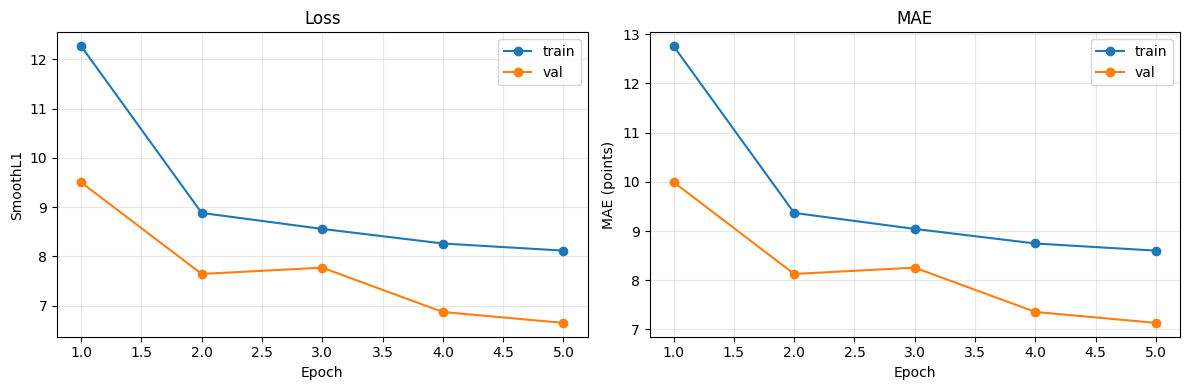

Saved: runs\train3\train_val_curves.png


In [51]:
import json

import matplotlib.pyplot as plt
import pandas as pd

# 학습 단계에서 저장한 history.json 을 다시 로드
history_path = out_dir / "history.json"
if history_path.exists():
    history_df = pd.DataFrame(json.loads(history_path.read_text(encoding="utf-8")))
else:
    raise FileNotFoundError("training history not found. Run training cell first.")

# 좌: SmoothL1 Loss / 우: MAE
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train")
axes[0].plot(history_df["epoch"], history_df["val_loss"], marker="o", label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("SmoothL1")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["train_mae"], marker="o", label="train")
axes[1].plot(history_df["epoch"], history_df["val_mae"], marker="o", label="val")
axes[1].set_title("MAE")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE (points)")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
curve_path = out_dir / "train_val_curves.png"
plt.savefig(curve_path, dpi=150)
plt.show()
print(f"Saved: {curve_path}")


## 테스트셋 예측 시각화

베스트 체크포인트로 테스트셋 추론을 다시 수행하고:

1. 샘플 게임 3개의 시간축 곡선 — 각 게임마다 4개 패널을 그린다
   - 잔여 점수 (홈/원정): 실제(true) vs 예측(pred)
   - **최종 점수** (홈/원정): 실제 최종 점수 vs **현재 점수 + 예측 잔여** (pred_final). 이벤트가 진행될수록 예측 최종이 실제 최종으로 수렴해야 함
2. 전체 산점도 — 모든 (true, pred) 쌍을 뿌려 대각선과의 편차를 한눈에 확인
3. 홈/원정 각각의 평균 절대 오차(MAE) 출력

산출물은 `runs/trainN/` 아래 `test_predictions.csv`, `test_prediction_timeline.png`, `test_prediction_scatter.png` 로 저장된다.

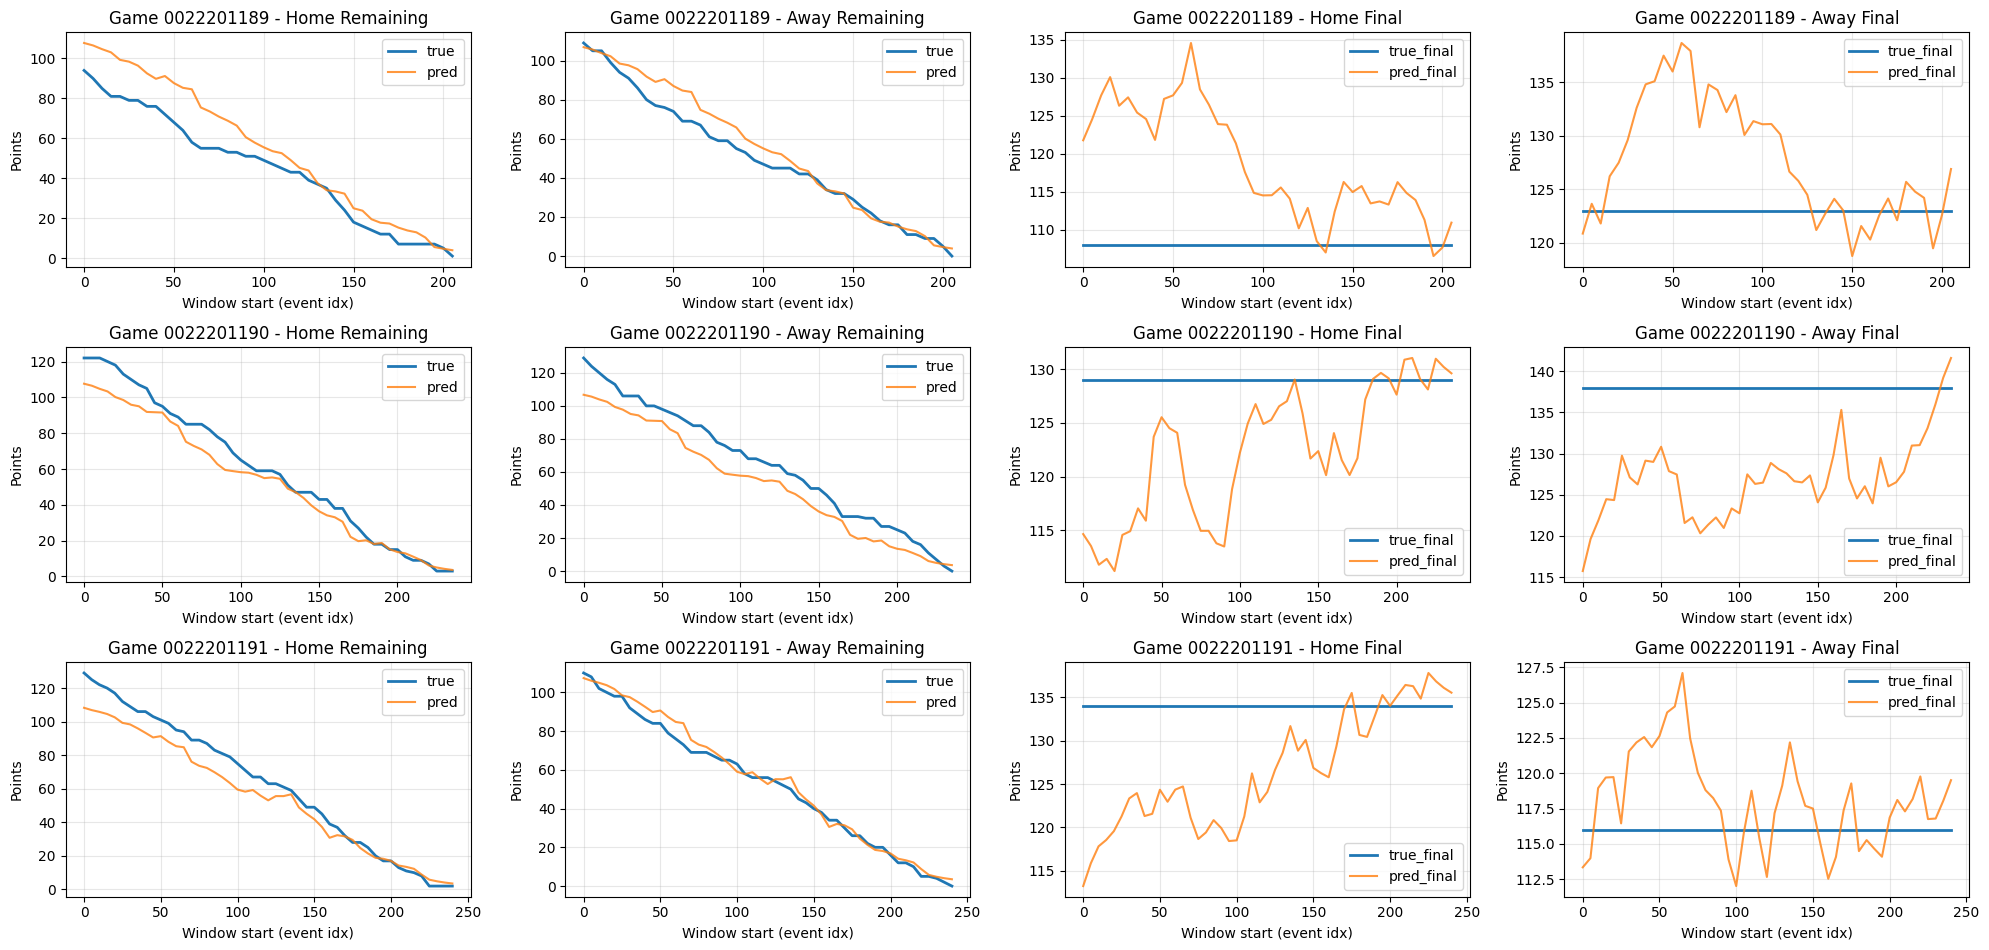

Saved: runs\train3\test_prediction_timeline.png


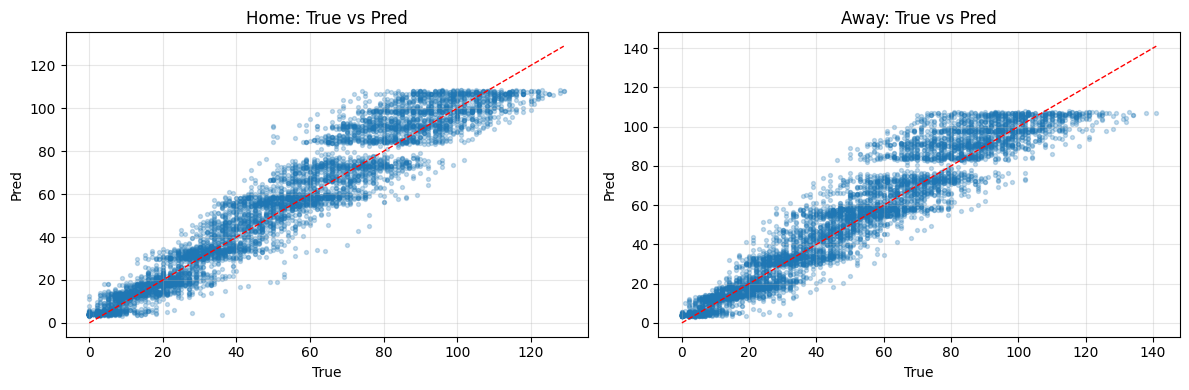

Saved: runs\train3\test_prediction_scatter.png
Test MAE - home: 7.0709, away: 7.6156, overall: 7.3432


In [52]:
import numpy as np


# numeric_feats 에서 누적 점수 컬럼이 몇 번째 인덱스인지 메타로부터 조회
num_cols = meta_loaded["numeric_feature_columns"]
HOME_PTS_IDX = num_cols.index("current_home_points")
AWAY_PTS_IDX = num_cols.index("current_away_points")


def collect_test_predictions(model, loader, device):
    """테스트 로더 전체에 대해 예측을 모아 long-format DataFrame 으로 반환.

    슬라이딩 윈도우 방식이므로 각 행은 한 윈도우의 마지막 이벤트에서의 예측이다.
    """
    model.eval()
    rows = []

    with torch.no_grad():
        for batch in loader:
            event_type_ids = batch["event_type_id"].to(device)
            numeric_feats  = batch["num_features"].to(device)
            targets        = batch["targets"].to(device)       # (B, 2)
            gameids        = batch["gameid"]
            window_starts  = batch["window_start"].cpu().numpy()

            preds = model(event_type_ids, numeric_feats)       # (B, 2)

            # 윈도우 마지막 이벤트의 누적 점수 ([:, -1, :])
            last_num = numeric_feats[:, -1, :].cpu().numpy()
            cur_h = last_num[:, HOME_PTS_IDX]
            cur_a = last_num[:, AWAY_PTS_IDX]

            for i, gid in enumerate(gameids):
                rows.append({
                    "gameid":              gid,
                    "window_start":        int(window_starts[i]),
                    "current_home_points": float(cur_h[i]),
                    "current_away_points": float(cur_a[i]),
                    "pred_home_remaining": float(preds[i, 0].item()),
                    "pred_away_remaining": float(preds[i, 1].item()),
                    "true_home_remaining": float(targets[i, 0].item()),
                    "true_away_remaining": float(targets[i, 1].item()),
                })

    return pd.DataFrame(rows)


# 베스트 체크포인트 로드
ckpt_path = out_dir / "best_score_prediction.pt"
if ckpt_path.exists():
    ckpt = torch.load(ckpt_path, map_location=device)
    if "model_state_dict" in ckpt:
        model.load_state_dict(ckpt["model_state_dict"])

pred_df = collect_test_predictions(model, loaders["test"], device)
if pred_df.empty:
    raise ValueError("No predictions collected from test loader")

pred_df["pred_home_final"] = pred_df["current_home_points"] + pred_df["pred_home_remaining"]
pred_df["pred_away_final"] = pred_df["current_away_points"] + pred_df["pred_away_remaining"]
pred_df["true_home_final"] = pred_df["current_home_points"] + pred_df["true_home_remaining"]
pred_df["true_away_final"] = pred_df["current_away_points"] + pred_df["true_away_remaining"]

pred_df.to_csv(out_dir / "test_predictions.csv", index=False)

# 샘플 게임 3개의 시간축 곡선 (window_start 기준 정렬)
sample_gameids = pred_df["gameid"].drop_duplicates().head(3).tolist()
fig, axes = plt.subplots(
    len(sample_gameids), 4,
    figsize=(20, 3.2 * len(sample_gameids)),
    sharex=False,
)
if len(sample_gameids) == 1:
    axes = np.array([axes])

for r, gid in enumerate(sample_gameids):
    g = pred_df[pred_df["gameid"] == gid].sort_values("window_start")

    axes[r, 0].plot(g["window_start"], g["true_home_remaining"], label="true", linewidth=2)
    axes[r, 0].plot(g["window_start"], g["pred_home_remaining"], label="pred", alpha=0.8)
    axes[r, 0].set_title(f"Game {gid} - Home Remaining")
    axes[r, 0].set_xlabel("Window start (event idx)")
    axes[r, 0].set_ylabel("Points")
    axes[r, 0].grid(alpha=0.3); axes[r, 0].legend()

    axes[r, 1].plot(g["window_start"], g["true_away_remaining"], label="true", linewidth=2)
    axes[r, 1].plot(g["window_start"], g["pred_away_remaining"], label="pred", alpha=0.8)
    axes[r, 1].set_title(f"Game {gid} - Away Remaining")
    axes[r, 1].set_xlabel("Window start (event idx)")
    axes[r, 1].set_ylabel("Points")
    axes[r, 1].grid(alpha=0.3); axes[r, 1].legend()

    axes[r, 2].plot(g["window_start"], g["true_home_final"], label="true_final", linewidth=2)
    axes[r, 2].plot(g["window_start"], g["pred_home_final"], label="pred_final", alpha=0.8)
    axes[r, 2].set_title(f"Game {gid} - Home Final")
    axes[r, 2].set_xlabel("Window start (event idx)")
    axes[r, 2].set_ylabel("Points")
    axes[r, 2].grid(alpha=0.3); axes[r, 2].legend()

    axes[r, 3].plot(g["window_start"], g["true_away_final"], label="true_final", linewidth=2)
    axes[r, 3].plot(g["window_start"], g["pred_away_final"], label="pred_final", alpha=0.8)
    axes[r, 3].set_title(f"Game {gid} - Away Final")
    axes[r, 3].set_xlabel("Window start (event idx)")
    axes[r, 3].set_ylabel("Points")
    axes[r, 3].grid(alpha=0.3); axes[r, 3].legend()

plt.tight_layout()
timeline_path = out_dir / "test_prediction_timeline.png"
plt.savefig(timeline_path, dpi=150)
plt.show()
print(f"Saved: {timeline_path}")

# 전체 산점도
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
max_home = max(pred_df["true_home_remaining"].max(), pred_df["pred_home_remaining"].max())
max_away = max(pred_df["true_away_remaining"].max(), pred_df["pred_away_remaining"].max())

axes[0].scatter(pred_df["true_home_remaining"], pred_df["pred_home_remaining"], s=8, alpha=0.25)
axes[0].plot([0, max_home], [0, max_home], "r--", linewidth=1)
axes[0].set_title("Home: True vs Pred"); axes[0].set_xlabel("True"); axes[0].set_ylabel("Pred"); axes[0].grid(alpha=0.3)

axes[1].scatter(pred_df["true_away_remaining"], pred_df["pred_away_remaining"], s=8, alpha=0.25)
axes[1].plot([0, max_away], [0, max_away], "r--", linewidth=1)
axes[1].set_title("Away: True vs Pred"); axes[1].set_xlabel("True"); axes[1].set_ylabel("Pred"); axes[1].grid(alpha=0.3)

plt.tight_layout()
scatter_path = out_dir / "test_prediction_scatter.png"
plt.savefig(scatter_path, dpi=150)
plt.show()
print(f"Saved: {scatter_path}")

mae_home = (pred_df["pred_home_remaining"] - pred_df["true_home_remaining"]).abs().mean()
mae_away = (pred_df["pred_away_remaining"] - pred_df["true_away_remaining"]).abs().mean()
print(f"Test MAE - home: {mae_home:.4f}, away: {mae_away:.4f}, overall: {(mae_home + mae_away) / 2:.4f}")


## 이벤트 단위 예측 변화 시각화

테스트셋에서 한 게임을 골라 **각 이벤트마다 모델 예측이 어떻게 변하는지** 자세히 들여다본다.

- step별로 이벤트 메타정보(`period`, `clock`, `event_type`, `desc`, `team_side`, 누적 점수)와 예측·정답을 한 테이블(`detail_df`)로 묶는다.
- 시각화는 6개 패널로 구성한다.
  1. 홈 잔여 점수 (true vs pred) — 큰 변화 step 에는 이벤트 타입 어노테이션
  2. 어웨이 잔여 점수 (true vs pred)
  3. 홈 최종 점수 (실제 최종 vs 현재+예측잔여)
  4. 어웨이 최종 점수
  5. step별 예측 변화량 Δpred_home_remaining — 이벤트 타입별 색상 막대
  6. step별 예측 변화량 Δpred_away_remaining
- 추가로 **예측 변화량 상위 K개 이벤트**를 표로 출력해 "어떤 이벤트가 모델 판단을 가장 크게 흔들었는가"를 본다.

산출물은 `runs/trainN/event_predictions_<gameid>.csv` 와 `event_predictions_timeline_<gameid>.png` 로 저장된다.

In [53]:
# __EVENT_LEVEL_VIZ_V1__
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from pathlib import Path


def build_event_detail_df(
    gameid: str,
    model,
    device,
    processed_df: pd.DataFrame,
    meta: dict,
    out_dir: Path | None = None,
    save_csv: bool = True,
) -> pd.DataFrame:
    """한 게임에 대해 슬라이딩 윈도우 추론을 수행하고 step별 예측 변화를 담은 DataFrame 반환.

    meta['window_config']['window_size'] 크기 윈도우를 stride 간격으로 생성해
    각 윈도우의 마지막 이벤트에서 잔여 점수를 예측한다.
    """
    game_df = processed_df[processed_df["gameid"] == gameid].reset_index(drop=True)
    if len(game_df) == 0:
        raise ValueError(f"No events found for gameid={gameid}")

    W = meta["window_config"]["window_size"]
    S = meta["window_config"]["stride"]
    numeric_cols = meta["numeric_feature_columns"]

    model.eval()
    window_rows = []

    start = 0
    while start + W <= len(game_df):
        end = start + W
        e_ids = torch.tensor(
            game_df["event_type_id"].iloc[start:end].to_numpy(), dtype=torch.long
        ).unsqueeze(0).to(device)
        n_feat = torch.tensor(
            game_df[numeric_cols].iloc[start:end].to_numpy(dtype=np.float32), dtype=torch.float32
        ).unsqueeze(0).to(device)

        with torch.no_grad():
            pred = model(e_ids, n_feat).squeeze(0).cpu().numpy()  # (2,)

        last = game_df.iloc[end - 1]
        window_rows.append({
            "step":                 end - 1,
            "window_start":         start,
            "period":               last["period"],
            "clock_sec_remaining":  last["clock_sec_remaining"],
            "elapsed_game_sec":     last["elapsed_game_sec"],
            "event_type":           last["event_type"],
            "desc":                 last.get("desc", ""),
            "team_side":            last["team_side"],
            "current_home":         last["current_home_points"],
            "current_away":         last["current_away_points"],
            "true_home_remaining":  last["remaining_home_points"],
            "true_away_remaining":  last["remaining_away_points"],
            "pred_home_remaining":  float(pred[0]),
            "pred_away_remaining":  float(pred[1]),
        })
        start += S

    if len(window_rows) == 0:
        raise ValueError(f"Game {gameid} has fewer than {W} events; cannot generate windows.")

    detail = pd.DataFrame(window_rows)
    detail["pred_home_final"] = detail["current_home"] + detail["pred_home_remaining"]
    detail["pred_away_final"] = detail["current_away"] + detail["pred_away_remaining"]
    detail["true_home_final"] = detail["current_home"] + detail["true_home_remaining"]
    detail["true_away_final"] = detail["current_away"] + detail["true_away_remaining"]
    detail["pred_home_delta"] = detail["pred_home_remaining"].diff().fillna(0.0)
    detail["pred_away_delta"] = detail["pred_away_remaining"].diff().fillna(0.0)
    detail["pred_total_abs_delta"] = detail["pred_home_delta"].abs() + detail["pred_away_delta"].abs()
    detail["pred_home_final_delta"] = detail["pred_home_final"].diff().fillna(0.0)
    detail["pred_away_final_delta"] = detail["pred_away_final"].diff().fillna(0.0)
    detail["pred_total_abs_final_delta"] = detail["pred_home_final_delta"].abs() + detail["pred_away_final_delta"].abs()

    if save_csv and out_dir is not None:
        path = Path(out_dir) / f"event_predictions_{gameid}.csv"
        detail.to_csv(path, index=False)
        print(f"Saved detail CSV: {path}")

    return detail


def _format_clock(period: int, clock_sec: float) -> str:
    m, s = divmod(int(round(clock_sec)), 60)
    return f"Q{period} {m:02d}:{s:02d}"


def plot_event_level_predictions(
    detail_df: pd.DataFrame,
    gameid: str,
    out_dir: Path | None = None,
    top_k: int = 10,
    annotate_k: int = 6,
):
    """이벤트 단위 예측 변화를 6패널로 시각화."""
    detail_df = detail_df.reset_index(drop=True)
    steps = detail_df["step"].to_numpy()

    event_types = sorted(detail_df["event_type"].unique().tolist())
    event_palette = plt.get_cmap("tab10", max(len(event_types), 1))
    event_color = {et: event_palette(i) for i, et in enumerate(event_types)}

    def _side_label(side: float) -> str:
        if side >= 0.75: return "Home"
        if side <= 0.25: return "Away"
        return "None"

    side_to_hatch = {"Home": "", "Away": "///", "None": "..."}
    side_labels_per_row = [_side_label(s) for s in detail_df["team_side"].to_numpy()]
    bar_colors = [event_color[et] for et in detail_df["event_type"]]
    bar_hatches = [side_to_hatch[lbl] for lbl in side_labels_per_row]
    top_idx = detail_df["pred_total_abs_final_delta"].nlargest(annotate_k).index.tolist()

    fig, axes = plt.subplots(3, 2, figsize=(18, 13), sharex=True)
    (ax_hr, ax_ar), (ax_hf, ax_af), (ax_hd, ax_ad) = axes

    ax_hr.plot(steps, detail_df["true_home_remaining"], label="true", color="C0", linewidth=2)
    ax_hr.plot(steps, detail_df["pred_home_remaining"], label="pred", color="C1", alpha=0.85)
    ax_hr.set_title(f"Game {gameid} — Home Remaining"); ax_hr.set_ylabel("Points"); ax_hr.grid(alpha=0.3); ax_hr.legend(loc="upper right")

    ax_ar.plot(steps, detail_df["true_away_remaining"], label="true", color="C0", linewidth=2)
    ax_ar.plot(steps, detail_df["pred_away_remaining"], label="pred", color="C1", alpha=0.85)
    ax_ar.set_title(f"Game {gameid} — Away Remaining"); ax_ar.set_ylabel("Points"); ax_ar.grid(alpha=0.3); ax_ar.legend(loc="upper right")

    ax_hf.plot(steps, detail_df["true_home_final"], label="true_final", color="C0", linewidth=2)
    ax_hf.plot(steps, detail_df["pred_home_final"], label="pred_final", color="C1", alpha=0.85)
    ax_hf.set_title(f"Game {gameid} — Home Final"); ax_hf.set_ylabel("Points"); ax_hf.grid(alpha=0.3); ax_hf.legend(loc="lower right")

    ax_af.plot(steps, detail_df["true_away_final"], label="true_final", color="C0", linewidth=2)
    ax_af.plot(steps, detail_df["pred_away_final"], label="pred_final", color="C1", alpha=0.85)
    ax_af.set_title(f"Game {gameid} — Away Final"); ax_af.set_ylabel("Points"); ax_af.grid(alpha=0.3); ax_af.legend(loc="lower right")

    bars_h = ax_hd.bar(steps, detail_df["pred_home_final_delta"], color=bar_colors, width=1.0, edgecolor="black", linewidth=0.3)
    for bar, hatch in zip(bars_h, bar_hatches): bar.set_hatch(hatch)
    ax_hd.axhline(0, color="black", linewidth=0.5)
    ax_hd.set_title("per window delta pred_home_final"); ax_hd.set_xlabel("Event step (window end)"); ax_hd.set_ylabel("Delta Points"); ax_hd.grid(alpha=0.3)

    bars_a = ax_ad.bar(steps, detail_df["pred_away_final_delta"], color=bar_colors, width=1.0, edgecolor="black", linewidth=0.3)
    for bar, hatch in zip(bars_a, bar_hatches): bar.set_hatch(hatch)
    ax_ad.axhline(0, color="black", linewidth=0.5)
    ax_ad.set_title("per window delta pred_away_final"); ax_ad.set_xlabel("Event step (window end)"); ax_ad.set_ylabel("Delta Points"); ax_ad.grid(alpha=0.3)

    for idx in top_idx:
        row = detail_df.loc[idx]
        label = f"{int(row['step'])}: {row['event_type']}"
        if abs(row["pred_home_final_delta"]) >= abs(row["pred_away_final_delta"]):
            ax = ax_hf; y = row["pred_home_final"]
        else:
            ax = ax_af; y = row["pred_away_final"]
        ax.annotate(label, xy=(row["step"], y), xytext=(0, 18), textcoords="offset points",
                    fontsize=8, ha="center", arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))

    from matplotlib.patches import Patch
    side_order = {"Home": 0, "Away": 1, "None": 2}
    combos_present = sorted(
        set(zip(detail_df["event_type"], side_labels_per_row)),
        key=lambda x: (side_order[x[1]], event_types.index(x[0])),
    )
    combo_handles = [
        Patch(facecolor=event_color[et], edgecolor="black", hatch=side_to_hatch[side], label=f"{side} {et}")
        for et, side in combos_present
    ]
    fig.legend(combo_handles, [h.get_label() for h in combo_handles],
               loc="lower center", ncol=min(len(combo_handles), 6),
               bbox_to_anchor=(0.5, -0.02), title="막대 = 팀(해칭) x 이벤트(색)", fontsize=8)

    fig.suptitle(f"Event-level prediction trace — game {gameid}", fontsize=14)
    plt.tight_layout(rect=(0, 0.03, 1, 0.97))

    if out_dir is not None:
        path = Path(out_dir) / f"event_predictions_timeline_{gameid}.png"
        plt.savefig(path, dpi=150, bbox_inches="tight")
        print(f"Saved: {path}")
    plt.show()

    top = (
        detail_df.nlargest(top_k, "pred_total_abs_final_delta")
        [["step", "period", "clock_sec_remaining", "event_type", "desc", "team_side",
          "current_home", "current_away", "pred_home_final_delta", "pred_away_final_delta",
          "pred_home_final", "pred_away_final"]]
        .copy()
    )
    top["clock"] = [_format_clock(int(p), float(c)) for p, c in zip(top["period"], top["clock_sec_remaining"])]
    display_cols = ["step", "clock", "event_type", "desc", "team_side",
                    "current_home", "current_away", "pred_home_final_delta", "pred_away_final_delta"]
    print(f"\n=== 최종 점수 예측 변화량 상위 {top_k}개 이벤트 (gameid={gameid}) ===")
    with pd.option_context("display.max_colwidth", 60, "display.width", 160):
        print(top[display_cols].to_string(index=False))
    return top


Inspecting gameid=0022201211
Saved detail CSV: runs\train3\event_predictions_0022201211.csv
windows: 45 | final true score: home=97 away=119


C:\Users\jaehy\AppData\Local\Temp\ipykernel_24404\3907161602.py:178: UserWarning: Glyph 47561 (\N{HANGUL SYLLABLE MAG}) missing from font(s) DejaVu Sans.
  plt.savefig(path, dpi=150, bbox_inches="tight")
C:\Users\jaehy\AppData\Local\Temp\ipykernel_24404\3907161602.py:178: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.savefig(path, dpi=150, bbox_inches="tight")
C:\Users\jaehy\AppData\Local\Temp\ipykernel_24404\3907161602.py:178: UserWarning: Glyph 54016 (\N{HANGUL SYLLABLE TIM}) missing from font(s) DejaVu Sans.
  plt.savefig(path, dpi=150, bbox_inches="tight")
C:\Users\jaehy\AppData\Local\Temp\ipykernel_24404\3907161602.py:178: UserWarning: Glyph 54644 (\N{HANGUL SYLLABLE HAE}) missing from font(s) DejaVu Sans.
  plt.savefig(path, dpi=150, bbox_inches="tight")
C:\Users\jaehy\AppData\Local\Temp\ipykernel_24404\3907161602.py:178: UserWarning: Glyph 52845 (\N{HANGUL SYLLABLE CING}) missing from font(s) DejaVu Sans.
  plt.savefig(path, dpi=150, 

Saved: runs\train3\event_predictions_timeline_0022201211.png


c:\Users\jaehy\.conda\envs\dl\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47561 (\N{HANGUL SYLLABLE MAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\jaehy\.conda\envs\dl\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\jaehy\.conda\envs\dl\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54016 (\N{HANGUL SYLLABLE TIM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\jaehy\.conda\envs\dl\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54644 (\N{HANGUL SYLLABLE HAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\jaehy\.conda\envs\dl\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52845 (\N{HANGUL SYLLABLE CING}) missing from font(s) DejaVu Sans.
  fig.

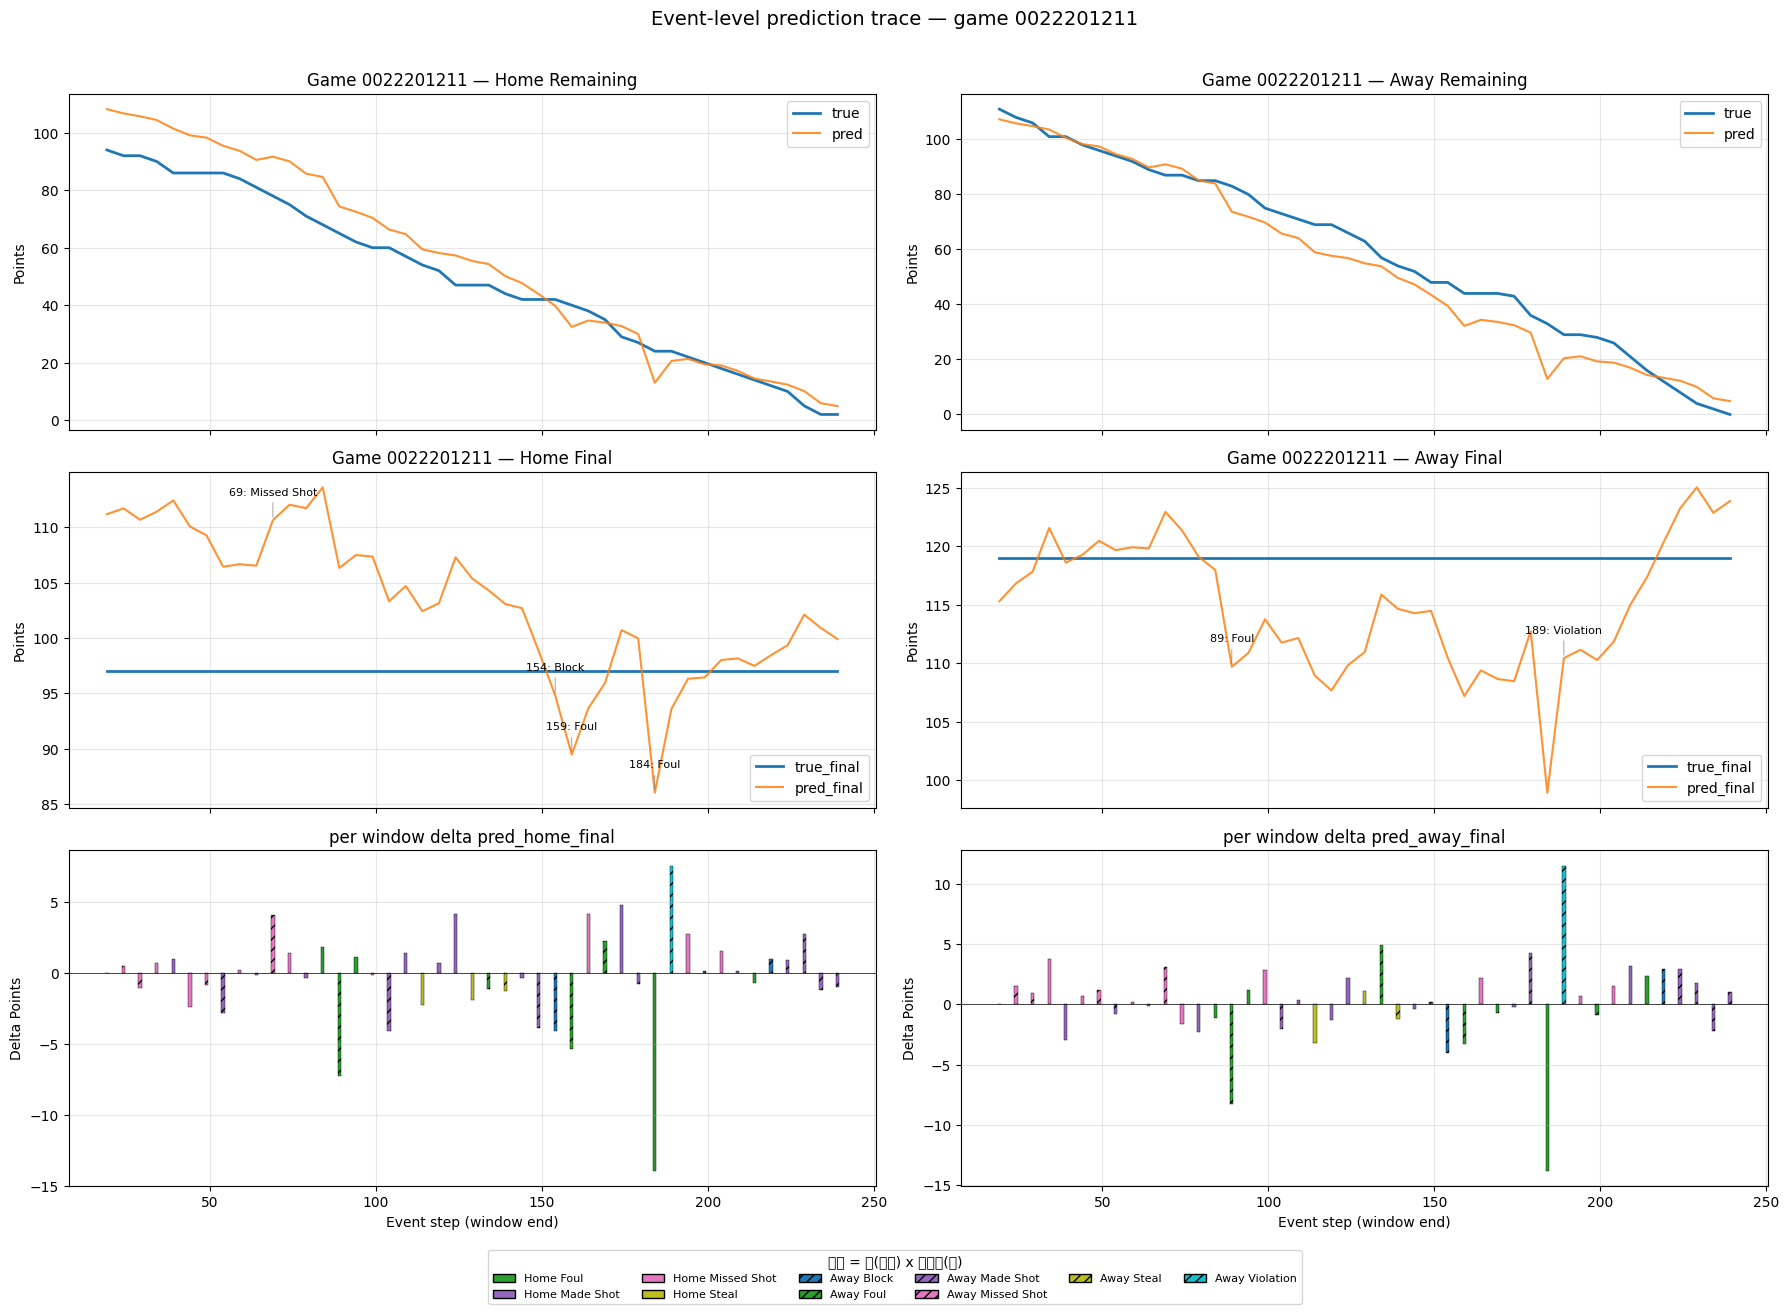


=== 최종 점수 예측 변화량 상위 10개 이벤트 (gameid=0022201211) ===
 step    clock  event_type                                              desc  team_side  current_home  current_away  pred_home_final_delta  pred_away_final_delta
  184 Q4 11:47        Foul                    Lyles S.FOUL (P2.T1) (J.Tiven)        1.0          73.0          86.0             -13.944276             -13.811630
  189 Q4 11:17   Violation                                              Lane        0.0          73.0          90.0               7.573096              11.511412
   89 Q2 06:49        Foul                  Kuminga P.FOUL (P1.T1) (B.Forte)        0.0          32.0          36.0              -7.274124              -8.287628
  159 Q3 05:01        Foul                 D. Green P.FOUL (P3.T3) (J.Tiven)        0.0          57.0          75.0              -5.349731              -3.277695
  154 Q3 06:15       Block                            Thompson BLOCK (2 BLK)        0.0          55.0          71.0              -4.04718

In [54]:
# __EVENT_LEVEL_VIZ_V1__
# 테스트셋에서 게임을 골라 이벤트 단위 예측 변화를 시각화한다.
# 슬라이딩 윈도우 방식이므로 stride 간격으로 예측점이 생성된다.
test_gameids = list(dict.fromkeys(s["gameid"] for s in test_loaded))
target_gameid = test_gameids[22]
print(f"Inspecting gameid={target_gameid}")

detail_df = build_event_detail_df(
    gameid=target_gameid,
    model=model,
    device=device,
    processed_df=processed_df,
    meta=meta_loaded,
    out_dir=out_dir,
    save_csv=True,
)
print(f"windows: {len(detail_df)} | "
      f"final true score: home={detail_df['true_home_final'].iloc[-1]:.0f} "
      f"away={detail_df['true_away_final'].iloc[-1]:.0f}")

top_events = plot_event_level_predictions(
    detail_df,
    gameid=target_gameid,
    out_dir=out_dir,
    top_k=10,
    annotate_k=6,
)
